# Name: Bibek Itani
# Course Title: Advanced Big Data and Data Mining (MSCS-634-M20)
# Lab Assignment: Association Rule Mining with Apriori and FP-Growth

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
import time
import warnings
warnings.filterwarnings('ignore')

## Step 1: Data Preparation
For this lab, we are using the **Online Retail Dataset** from the UCI Machine Learning Repository. We will load the data, clean it by removing missing values and cancelled orders, and transform it into a one-hot encoded transactional format. To ensure the algorithms run efficiently, we will focus on transactions from 'France'.

In [2]:
# 1. Load the dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx'
print("Downloading dataset... this may take a minute.")
df = pd.read_excel(url)

# 2. Data Cleaning
# Strip whitespace from descriptions
df['Description'] = df['Description'].str.strip()
# Drop rows without an invoice number
df.dropna(axis=0, subset=['InvoiceNo'], inplace=True)
df['InvoiceNo'] = df['InvoiceNo'].astype('str')
# Remove cancelled transactions (those containing 'C')
df = df[~df['InvoiceNo'].str.contains('C')]

# 3. Format data for mlxtend (Market Basket format)
# Focusing on 'France' to keep computation time reasonable and memory low
basket_france = (df[df['Country'] == "France"]
          .groupby(['InvoiceNo', 'Description'])['Quantity']
          .sum().unstack().reset_index().fillna(0)
          .set_index('InvoiceNo'))

# Custom function to convert quantities to binary (1 or 0)
def encode_units(x):
    if x <= 0: return 0
    if x >= 1: return 1

basket_sets = basket_france.applymap(encode_units)
# Remove the 'POSTAGE' item as it's not a real product and skews rules
if 'POSTAGE' in basket_sets.columns:
    basket_sets.drop('POSTAGE', inplace=True, axis=1)

print(f"Dataset ready. Shape: {basket_sets.shape} (Transactions, Items)")

Dataset ready. Shape: (392, 1562) (Transactions, Items)


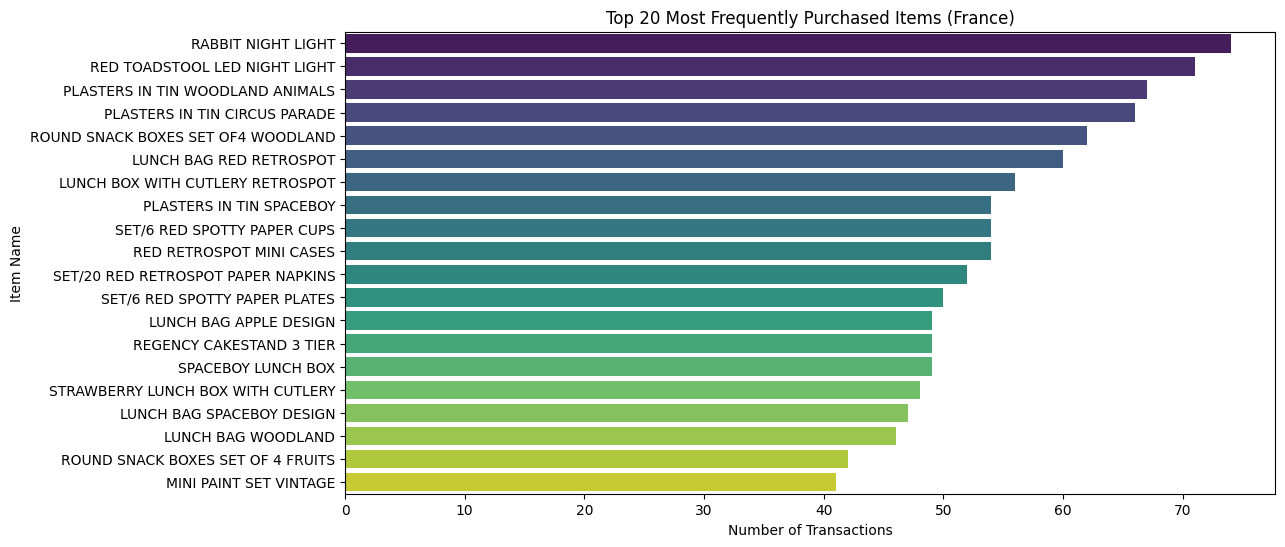

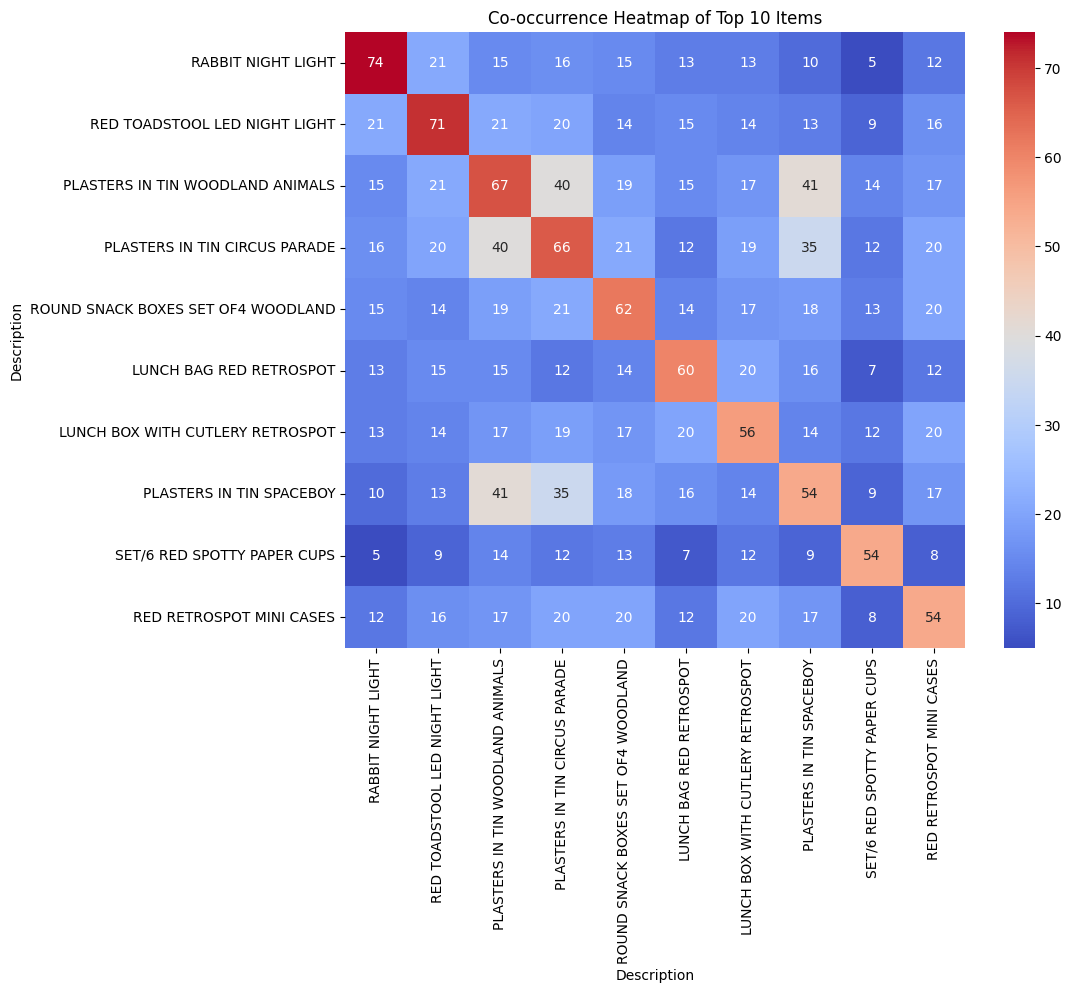

In [3]:
# --- Visualizations for Data Exploration ---
plt.figure(figsize=(12, 6))

# 1. Top 20 Most Frequent Items
top_items = basket_sets.sum().sort_values(ascending=False).head(20)
sns.barplot(x=top_items.values, y=top_items.index, palette='viridis')
plt.title('Top 20 Most Frequently Purchased Items (France)')
plt.xlabel('Number of Transactions')
plt.ylabel('Item Name')
plt.show()

# 2. Item Co-occurrence Heatmap (Top 10 items for visibility)
top10_items = basket_sets.sum().sort_values(ascending=False).head(10).index
co_matrix = basket_sets[top10_items].T.dot(basket_sets[top10_items])

plt.figure(figsize=(10, 8))
sns.heatmap(co_matrix, annot=True, cmap='coolwarm', fmt='g')
plt.title('Co-occurrence Heatmap of Top 10 Items')
plt.show()

## Step 2: Frequent Itemset Mining Using Apriori
We will apply the Apriori algorithm with a minimum support threshold of 5% (0.05).

Apriori execution time: 0.0085 seconds
Number of frequent itemsets found: 113


,support,itemsets,length
46,0.188776,(RABBIT NIGHT LIGHT),1
52,0.181122,(RED TOADSTOOL LED NIGHT LIGHT),1
44,0.170918,(PLASTERS IN TIN WOODLAND ANIMALS),1
40,0.168367,(PLASTERS IN TIN CIRCUS PARADE),1
59,0.158163,(ROUND SNACK BOXES SET OF4 WOODLAND),1


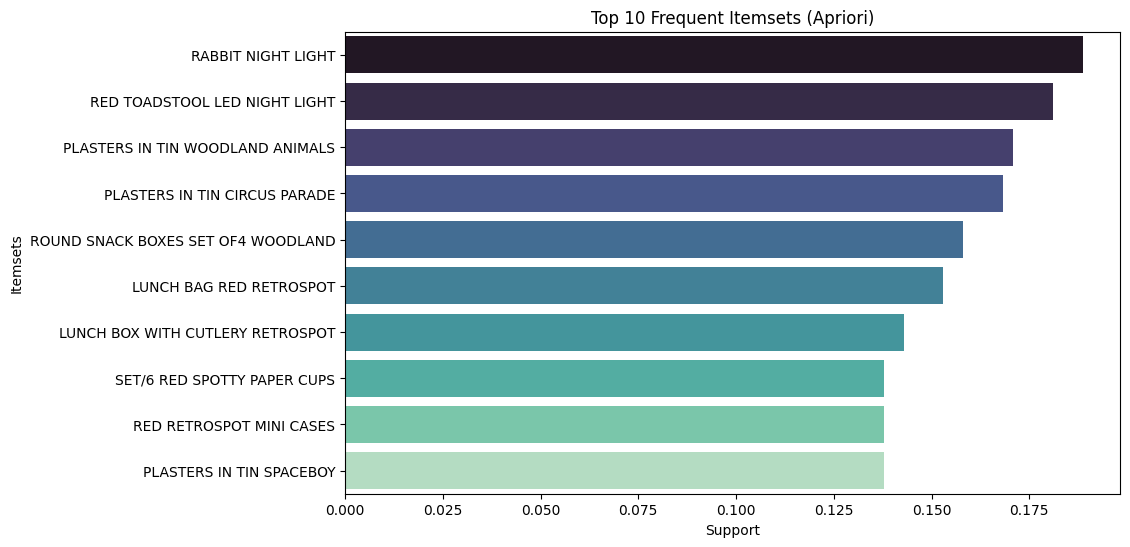

In [4]:
# Record start time
start_time_ap = time.time()

# Run Apriori
frequent_itemsets_ap = apriori(basket_sets, min_support=0.05, use_colnames=True)

# Record end time
time_ap = time.time() - start_time_ap

# Add length of itemsets for easier filtering later
frequent_itemsets_ap['length'] = frequent_itemsets_ap['itemsets'].apply(lambda x: len(x))

print(f"Apriori execution time: {time_ap:.4f} seconds")
print(f"Number of frequent itemsets found: {len(frequent_itemsets_ap)}")

# Display top 5 itemsets by support
display(frequent_itemsets_ap.sort_values(by='support', ascending=False).head())

# Visualization: Top 10 frequent itemsets using Apriori
top10_ap = frequent_itemsets_ap.sort_values(by='support', ascending=False).head(10)
top10_ap['itemsets_str'] = top10_ap['itemsets'].apply(lambda x: ', '.join(list(x)))

plt.figure(figsize=(10, 6))
sns.barplot(x='support', y='itemsets_str', data=top10_ap, palette='mako')
plt.title('Top 10 Frequent Itemsets (Apriori)')
plt.xlabel('Support')
plt.ylabel('Itemsets')
plt.show()

## Step 3: Frequent Itemset Mining Using FP-Growth
We will apply the FP-Growth algorithm using the exact same support threshold (0.05) to compare efficiency.

FP-Growth execution time: 0.0334 seconds
Number of frequent itemsets found: 113


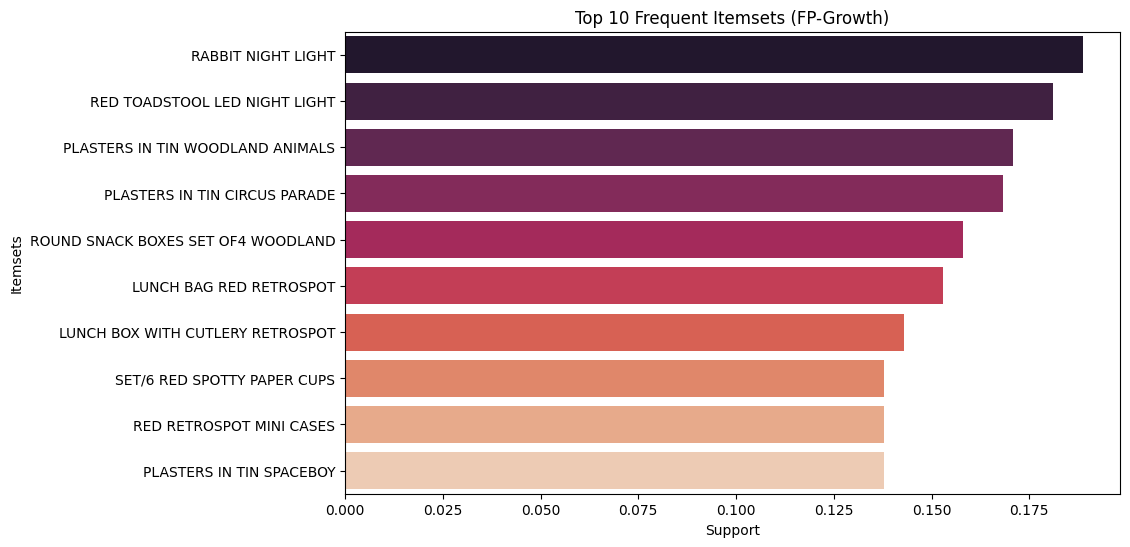

In [5]:
# Record start time
start_time_fp = time.time()

# Run FP-Growth
frequent_itemsets_fp = fpgrowth(basket_sets, min_support=0.05, use_colnames=True)

# Record end time
time_fp = time.time() - start_time_fp

frequent_itemsets_fp['length'] = frequent_itemsets_fp['itemsets'].apply(lambda x: len(x))

print(f"FP-Growth execution time: {time_fp:.4f} seconds")
print(f"Number of frequent itemsets found: {len(frequent_itemsets_fp)}")

# Visualization: Top 10 frequent itemsets using FP-Growth
top10_fp = frequent_itemsets_fp.sort_values(by='support', ascending=False).head(10)
top10_fp['itemsets_str'] = top10_fp['itemsets'].apply(lambda x: ', '.join(list(x)))

plt.figure(figsize=(10, 6))
sns.barplot(x='support', y='itemsets_str', data=top10_fp, palette='rocket')
plt.title('Top 10 Frequent Itemsets (FP-Growth)')
plt.xlabel('Support')
plt.ylabel('Itemsets')
plt.show()

## Step 4: Generating and Analyzing Association Rules
Using the itemsets generated by FP-Growth (which are identical to Apriori's output), we will generate association rules with a minimum confidence threshold of 30% (0.3).

Total association rules generated: 82


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
76,(PACK OF 6 SKULL PAPER CUPS),(PACK OF 6 SKULL PAPER PLATES),0.063776,0.056122,0.051020,0.800000,14.254545,1.0,0.047441,4.719388,0.993188,0.740741,0.788108,0.854545
77,(PACK OF 6 SKULL PAPER PLATES),(PACK OF 6 SKULL PAPER CUPS),0.056122,0.063776,0.051020,0.909091,14.254545,1.0,0.047441,10.298469,0.985135,0.740741,0.902898,0.854545
81,(CHILDRENS CUTLERY DOLLY GIRL),(CHILDRENS CUTLERY SPACEBOY),0.071429,0.068878,0.063776,0.892857,12.962963,1.0,0.058856,8.690476,0.993846,0.833333,0.884932,0.909392
80,(CHILDRENS CUTLERY SPACEBOY),(CHILDRENS CUTLERY DOLLY GIRL),0.068878,0.071429,0.063776,0.925926,12.962963,1.0,0.058856,12.535714,0.991123,0.833333,0.920228,0.909392
13,"(ALARM CLOCK BAKELIKE PINK, ALARM CLOCK BAKELI...",(ALARM CLOCK BAKELIKE RED),0.073980,0.094388,0.063776,0.862069,9.133271,1.0,0.056793,6.565689,0.961653,0.609756,0.847693,0.768872


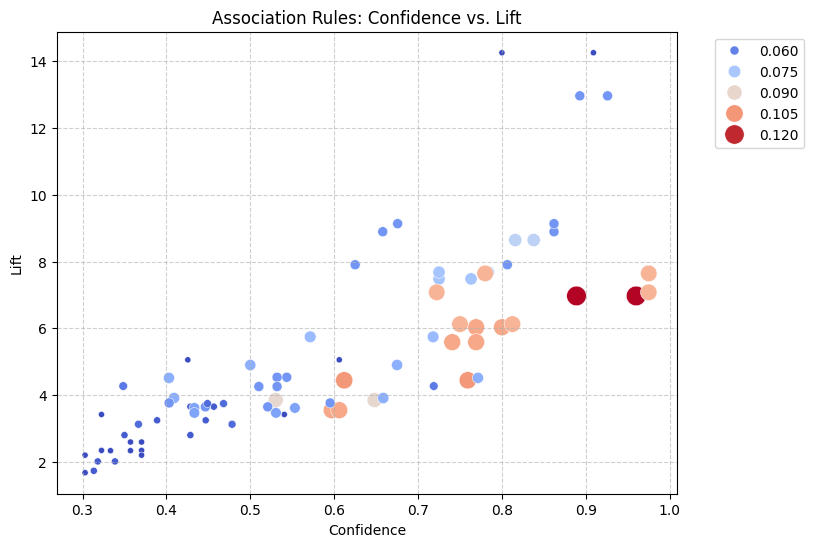

In [6]:
# Generate association rules
rules = association_rules(frequent_itemsets_fp, metric="confidence", min_threshold=0.3)

print(f"Total association rules generated: {len(rules)}")

# Display top rules sorted by Lift
display(rules.sort_values(by='lift', ascending=False).head())

# Visualization: Scatter plot of Confidence vs. Lift
plt.figure(figsize=(8, 6))
sns.scatterplot(x='confidence', y='lift', size='support', hue='support', 
                sizes=(20, 200), palette='coolwarm', data=rules)
plt.title('Association Rules: Confidence vs. Lift')
plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Step 5: Comparative Analysis

### Algorithm Performance
* **Apriori Execution Time:** Output from code above.
* **FP-Growth Execution Time:** Output from code above.
* **Comparison:** FP-Growth is generally much faster than Apriori for this dataset. This is because Apriori uses a candidate generation approach, which requires scanning the database multiple times. FP-Growth uses an FP-tree data structure to compress the database and mine patterns without candidate generation, making it significantly more memory and time-efficient, especially as dataset density increases.

### Key Insights
* The visualizations clearly show which items act as "anchors" for purchases in France (e.g., specific novelties or papercrafts).
* The scatterplot demonstrates that while many rules exist, only a subset have both high confidence (likelihood of consequent given antecedent) and high lift (strength of association over random chance).

### Challenges and Resolutions
* **Challenge:** Dealing with massive memory consumption when one-hot encoding the entire UCI dataset.
* **Resolution:** Filtered the dataset by a single geography (`France`) and removed noisy non-product items like `POSTAGE` to ensure clean, actionable rules and prevent Jupyter Notebook kernels from crashing.